In [4]:
import matplotlib.pyplot as plt
plt.style.use('default')
import pandas as pd
import math

In [5]:
import torch

# **Call Option Price**

In [3]:
class CallOptionPrice:
    """
    Valoración de Opciones de Compra (Call) mediante el Modelo Black-Scholes

    Implementa la fórmula analítica de Black-Scholes y estimaciones mediante
    Monte Carlo estándar, muestreo por importancia y métodos MCMC (Metropolis-Hastings).
    """

    def __init__(self, s_0, r, sigma, k, t):
        """
        Inicializa los parámetros de la opción call.

        Parámetros
        ----------
        s_0 : float
            Precio inicial del activo subyacente.
        r : float
            Tasa de interés libre de riesgo (continua).
        sigma : float
            Volatilidad del activo subyacente.
        k : float
            Precio de ejercicio (strike price).
        t : float
            Tiempo hasta vencimiento (en años).
        """
        self.s_0 = torch.Tensor([s_0])
        self.r = torch.Tensor([r])
        self.sigma = torch.Tensor([sigma])
        self.k = torch.Tensor([k])
        self.t = torch.Tensor([t])

        # Valor crítico theta: punto donde el payoff se vuelve positivo
        # Corresponde a z tal que S_T = K
        self.theta = (torch.log(self.k / self.s_0) - (self.r - self.sigma ** 2 / 2) * self.t) / (self.sigma * torch.sqrt(self.t))

        # Distribución normal estándar
        self.Z = torch.distributions.Normal(0.0, 1.0)

        # Precio analítico (se calcula cuando se necesita)
        self.price = None

    def payoff(self, z):
        """
        Calcula el payoff de la opción call en función de la variable normal Z.

        Parámetros
        ----------
        z : torch.Tensor
            Variable aleatoria normal estándar.

        Retorna
        -------
        torch.Tensor
            Payoff de la opción call: max(S_T - K, 0)
            donde S_T = S_0 * exp((r - σ²/2)t + σ√t Z)

        Notas
        -----
        El payoff es positivo solo cuando Z > θ, donde:
        θ = (log(K/S_0) - (r - σ²/2)t) / (σ√t)
        """
        payoff = torch.where(
            z <= self.theta,
            torch.zeros_like(z),
            self.s_0 * torch.exp((self.r - self.sigma**2/2) * self.t + self.sigma * torch.sqrt(self.t) * z) - self.k
        )
        return payoff

    def g_min_var(self, z):
        """
        Calcula la función de densidad de la distribución de mínima varianza.

        Esta distribución es óptima para muestreo por importancia, ya que
        minimiza la varianza del estimador.

        Parámetros
        ----------
        z : torch.Tensor
            Variable aleatoria normal estándar.

        Retorna
        -------
        torch.Tensor
            Densidad de la distribución de mínima varianza evaluada en z.

        Notas
        -----
        La distribución de mínima varianza tiene densidad:
        g(z) ∝ payoff(z) * φ(z)
        donde φ(z) es la densidad normal estándar.
        La constante de normalización es:
        c = √(2π) [S_0 e^{rt} Φ(θ - σ√t) - K Φ(θ)]
        """
        c = math.sqrt(2 * math.pi) * (
            self.s_0 * torch.exp(self.r * self.t) * (1 - self.Z.cdf(self.theta - self.sigma * torch.sqrt(self.t))) -
            self.k * (1 - self.Z.cdf(self.theta))
        )
        return self.payoff(z) * torch.exp(-z**2 / 2) / c

    def compute_price(self):
        """
        Calcula el precio analítico de la opción call mediante Black-Scholes.

        Utiliza la fórmula cerrada de Black-Scholes:
        C = S_0 Φ(d1) - K e^{-rt} Φ(d2)

        Parámetros
        ----------
        t : float
            Tiempo hasta vencimiento (en años).
        """
        # Parámetros d1 y d2 de Black-Scholes
        d1 = (torch.log(self.s_0 / self.k) + (self.r + self.sigma ** 2 / 2) * self.t) / (self.sigma * torch.sqrt(self.t))
        d2 = d1 - self.sigma * torch.sqrt(self.t)

        # Fórmula de Black-Scholes
        self.price = self.s_0 * self.Z.cdf(d1) - self.k * torch.exp(-self.r * self.t) * self.Z.cdf(d2)

    def compute_price_mc(self, n=10000, decimals=10):
        """
        Estima el precio mediante Monte Carlo estándar.

        Simula trayectorias del activo bajo la medida neutral al riesgo:
        S_T = S_0 * exp((r - σ²/2)T + σ√T Z)

        Parámetros
        ----------
        n : int, opcional
            Número de simulaciones. Por defecto 10,000.
        decimals : int, opcional
            Número de decimales para mostrar. Por defecto 10.

        Retorna
        -------
        tuple
            (precio_estimado, error_absoluto, varianza)

        Notas
        -----
        El estimador Monte Carlo estándar es:
        Ĉ = e^{-rt} * (1/n) * Σ payoff(Z_i)
        """
        # Calcular precio analítico para referencia
        self.compute_price()

        # Simular variable normal estándar
        z = self.Z.sample((n,))

        # Payoff de la opción call
        payoff = self.payoff(z)

        # Precio estimado (valor esperado descontado)
        price_hat = torch.exp(-self.r * self.t) * payoff.mean()

        # Varianza del estimador
        var = torch.exp(-2 * self.r * self.t) * payoff.var() / n

        # Error absoluto respecto al precio analítico
        error = torch.abs(self.price - price_hat)

        print("----- Monte Carlo -----")
        print(f"Precio  : {self.price.item():.{decimals}f}")
        print(f"Precio estimado : {price_hat.item():.{decimals}f}")
        print(f"Error: {error.item():.{decimals}f}")
        print(f"Varianza: {var.item():.{decimals}f}")

        return price_hat, error, var

    def compute_price_is(self, theta=None, n=10000, decimals=10):
        """
        Estima el precio mediante muestreo por importancia.

        Cambia la media de la distribución de Z para muestrear más eficientemente
        en regiones donde el payoff es positivo.

        Parámetros
        ----------
        theta : float, opcional
            Desplazamiento para la media en el muestreo por importancia.
            Si es None, se calcula automáticamente como el valor que hace
            que el activo esté en dinero (at-the-money).
        n : int, opcional
            Número de simulaciones. Por defecto 10,000.
        decimals : int, opcional
            Número de decimales para mostrar. Por defecto 10.

        Retorna
        -------
        tuple
            (precio_estimado, error_absoluto, varianza)

        Notas
        -----
        La distribución propuesta es N(θ, 1) para Z.
        Los pesos de importancia se calculan como:
        w(z) = exp(-θz + θ²/2)

        El estimador por importancia es:
        Ĉ = e^{-rt} * (1/n) * Σ payoff(Z_i) * w(Z_i)

        donde Z_i ~ N(θ, 1).
        """
        # Calcular theta óptimo si no se proporciona
        if theta is None:
            theta = self.theta
        else:
            theta = torch.Tensor([theta])

        # Calcular precio analítico
        self.compute_price()

        # Muestrear de la distribución propuesta (normal desplazada)
        z = self.Z.sample((n,)) + theta

        # Payoff de la opción
        payoff = self.payoff(z)

        # Pesos de importancia (razón de densidades)
        # f(z)/g(z) donde f es N(0,1) y g es N(θ,1)
        weights = torch.exp(-theta * z + theta ** 2 / 2)

        # Estimador por importancia
        estimator = payoff * weights
        price_hat = torch.exp(-self.r * self.t) * estimator.mean()

        # Varianza del estimador
        var = torch.exp(-2 * self.r * self.t) * estimator.var() / n

        # Error absoluto
        error = torch.abs(self.price - price_hat)

        print("----- Importance Sampling -----")
        print(f"Precio  : {self.price.item():.{decimals}f}")
        print(f"Precio estimado : {price_hat.item():.{decimals}f}")
        print(f"Error : {error.item():.{decimals}f}")
        print(f"Varianza : {var.item():.{decimals}f}")

        return price_hat, error, var

    def compute_price_mh(self, n=10000, decimals=10, n_chains=1, step_size=1.0, burn_in=None):
        """
        Estima el precio mediante el algoritmo Metropolis-Hastings (MCMC).

        Este método utiliza una cadena de Markov para muestrear de la distribución
        objetivo proporcional a payoff(z) * φ(z), que es óptima para el muestreo
        por importancia.

        Parámetros
        ----------
        n : int, opcional
            Número total de iteraciones de la cadena. Por defecto 10,000.
        decimals : int, opcional
            Número de decimales para mostrar. Por defecto 10.
        n_chains : int, opcional
            Número de cadenas paralelas. Por defecto 1.
        step_size : float, opcional
            Tamaño de paso para la distribución de propuesta. Por defecto 1.0.
        burn_in : int, opcional
            Número de iteraciones iniciales a descartar (periodo de calentamiento).
            Si es None, no se descartan iteraciones.

        Retorna
        -------
        tuple
            (precio_estimado, error_absoluto, varianza, muestras)

        Notas
        -----
        El algoritmo Metropolis-Hastings se utiliza para muestrear de:
        π(z) ∝ payoff(z) * φ(z)

        Luego, el precio se estima como:
        Ĉ = e^{-rt} * (1/m) * Σ payoff(z_i) * φ(z_i) / g(z_i)

        donde g es la distribución de mínima varianza y φ es la densidad normal.
        """
        # Inicializar cadenas
        x_n = torch.zeros((n, n_chains))

        # Algoritmo Metropolis-Hastings
        for i in range(n - 1):
            # Generar propuesta desde la distribución actual más ruido
            y = step_size * self.Z.sample((n_chains,)) + x_n[i]
            u = torch.rand((n_chains,))

            # Calcular log-razón de aceptación
            log_alpha = (torch.log(self.payoff(y)) + self.Z.log_prob(y) -
                        torch.log(self.payoff(x_n[i])) - self.Z.log_prob(x_n[i]))

            # Aceptación según criterio de Metropolis
            alpha = torch.minimum(torch.zeros_like(log_alpha), log_alpha)
            accept = torch.log(u) <= alpha

            # Actualizar cadena
            x_n[i + 1] = torch.where(accept, y, x_n[i])

        # Descartar periodo de calentamiento si se especifica
        if burn_in is not None:
            x_n = x_n[burn_in:]

        # Aplanar todas las cadenas
        x_n_flat = x_n.flatten()

        # Calcular payoff, densidad normal y densidad de mínima varianza
        payoff = self.payoff(x_n_flat)
        norm = self.Z.log_prob(x_n_flat).exp()
        g = self.g_min_var(x_n_flat)

        # Estimador por importancia con la muestra MCMC
        # Se usa la distribución de mínima varianza como distribución de importancia
        price_hat = (torch.exp(-self.r * self.t) * payoff * norm / g).mean()

        # Varianza del estimador
        var = (torch.exp(-self.r * self.t) * payoff * norm / g).var() / x_n_flat.shape[0]

        # Calcular precio analítico y error
        self.compute_price()
        error = torch.abs(self.price - price_hat)

        print("----- Metropolis-Hastings -----")
        print(f"Precio  : {self.price.item():.{decimals}f}")
        print(f"Precio estimado : {price_hat.item():.{decimals}f}")
        print(f"Error: {error.item():.{decimals}f}")
        print(f"Varianza: {var.item():.{decimals}f}")

        return price_hat, error, var, x_n_flat




In [4]:
s_0 = 100.0
r = 0.07
sigma = 0.5
k =105.0
t = 1
call_option = CallOptionPrice(s_0, r, sigma, k, t)


In [5]:
_, _, _, x_n = call_option.compute_price_mh(n=5000, n_chains=3, burn_in=1000)

----- Metropolis-Hastings -----
Precio  : 20.6006507874
Precio estimado : 20.6006469727
Error: 0.0000038147
Varianza: 0.0000000000


In [6]:
_, _, _ = call_option.compute_price_mc(n=1000000)

----- Monte Carlo -----
Precio  : 20.6006507874
Precio estimado : 20.5929031372
Error: 0.0077476501
Varianza: 0.0016343315


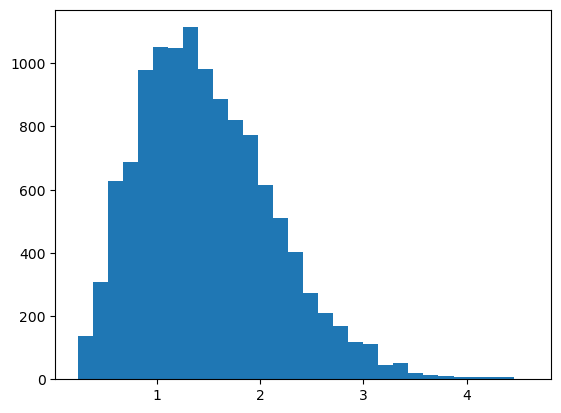

In [9]:
plt.hist(x_n,bins=30)
plt.show()

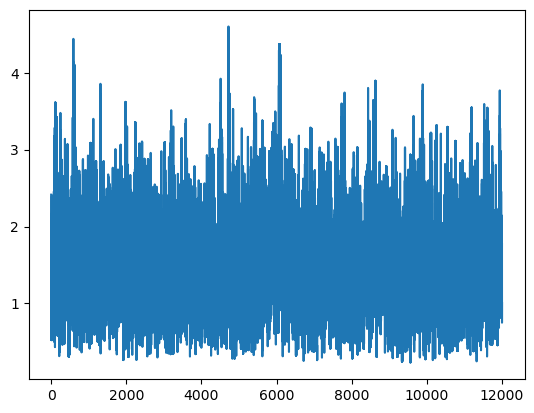

In [13]:
plt.plot(x_n)
plt.show()

# **Regresión Lineal Bayesiana**

In [60]:
class BayesianLinearRegression:
    """
    Modelo de Regresión Lineal Bayesiana implementado con Metropolis-Hastings.

    Implementa un modelo de regresión lineal con prior conjugado:
    - Beta ~ N(0, τ²I)
    - σ² ~ InverseGamma(a, b)

    La inferencia se realiza mediante muestreo MCMC con algoritmo de Metropolis-Hastings
    """

    def __init__(self, X, y, tau2=1.0, a=1.0, b=1.0):
        """
        Inicializa el modelo de regresión lineal bayesiana.

        Parámetros:
        -----------
        X : torch.Tensor
            Matriz de diseño de tamaño (n, d) donde n es número de muestras y d número de características
        y : torch.Tensor
            Vector de respuestas de tamaño (n,)
        tau2 : float, default=1.0
            Varianza a priori para los coeficientes beta (prior Gaussiano)
        a : float, default=1.0
            Parámetro de forma para el prior InverseGamma de σ²
        b : float, default=1.0
            Parámetro de escala para el prior InverseGamma de σ²
        """
        self.X = X  # Matriz de diseño
        self.y = y  # Vector de respuestas
        self.tau2 = tau2  # Varianza del prior para beta
        self.a = a  # Parámetro de forma del prior para sigma2
        self.b = b  # Parámetro de escala del prior para sigma2

        # Inicialización de parámetros del modelo
        self.beta = None  # Coeficientes estimados (media posterior)
        self.sigma2 = None  # Varianza del error estimada (media posterior)

        # Almacenamiento de muestras MCMC
        self.beta_samples = None  # Muestras de los coeficientes beta
        self.sigma2_samples = None  # Muestras de la varianza del error
        self.eta_samples = None  # Muestras de log(sigma2) para mejor muestreo

        # Dimensiones de los datos
        self.n, self.d = self.X.shape  # n: número de muestras, d: número de características

    def log_posterior(self, beta, sigma2):
        """
        Calcula el logaritmo de la densidad posterior no normalizada.

        La posterior es proporcional a: Likelihood × Prior(beta) × Prior(sigma²)

        Parámetros:
        -----------
        beta : torch.Tensor
            Vector de coeficientes de tamaño (d,)
        sigma2 : torch.Tensor
            Varianza del error (escalar)

        Retorna:
        --------
        torch.Tensor : Log-posterior no normalizada
        """
        # Calcular la media lineal: X (n, d) * beta.T(d,n_chain)
        z = self.X @ beta.mT  # Predicciones lineales

        # Log-verosimilitud: Normal(z, sigma²)
        like = torch.distributions.Normal(z, torch.sqrt(sigma2))
        log_like = like.log_prob(self.y[:, None]).sum(0)  # Suma sobre todas las muestras

        # Log-prior para beta: Normal Multivariada(0, τ²I)
        beta_prior = torch.distributions.MultivariateNormal(
            torch.zeros(self.d),  # Media cero
            self.tau2 * torch.eye(self.d)  # Matriz de covarianza diagonal
        )
        log_beta_prior = beta_prior.log_prob(beta)

        # Log-prior para sigma²: InverseGamma(a, b)
        sigma2_prior = torch.distributions.InverseGamma(self.a, self.b)
        log_sigma2_prior = sigma2_prior.log_prob(sigma2)

        # Transformación de Jacobiano para cambio de variable (eta = log sigma²)
        # Necesario porque estamos muestreando eta en lugar de sigma²
        eta = torch.log(sigma2)

        # Log-posterior no normalizada
        return log_like + log_beta_prior + log_sigma2_prior + eta

    def fit(self, n_iter=1000, burn_in=0, n_chains=1, step_size=0.5):
        """
        Ajusta el modelo mediante muestreo MCMC con Metropolis-Hastings.

        Implementa el algoritmo de Metropolis-Hastings para muestrear conjuntamente
        beta y sigma² usando un paso de Random Walk.

        Parámetros:
        -----------
        n_iter : int, default=1000
            Número de iteraciones MCMC
        burn_in : int, default=0
            Número de iteraciones a descartar al inicio (período de calentamiento)
        n_chains : int, default=1
            Número de cadenas MCMC paralelas
        step_size : float, default=0.5
            Tamaño del paso para el Random Walk (controla la aceptación)
        """
        # Inicializar cadenas MCMC
        beta = torch.zeros((n_chains, self.d))  # Valores iniciales de beta
        eta = torch.zeros((n_chains,))  # Valores iniciales de eta = log(sigma²)

        # Almacenamiento de muestras
        self.beta_samples = torch.zeros((n_iter, n_chains, self.d))
        self.eta_samples = torch.zeros((n_iter, n_chains))

        # Bucle principal MCMC
        for i in range(n_iter):
            # Generar propuestas usando Random Walk
            beta_prop = beta + step_size * torch.randn_like(beta)  # Propuesta para beta
            eta_prop = eta + step_size * torch.randn_like(eta)  # Propuesta para eta

            # Convertir eta a sigma²
            sigma2 = torch.exp(eta)
            sigma2_prop = torch.exp(eta_prop)

            # Calcular log-posterior para valores actuales y propuestos
            logp_current = self.log_posterior(beta, sigma2)
            logp_prop = self.log_posterior(beta_prop, sigma2_prop)

            # Calcular log-ratio de aceptación (Metropolis-Hastings)
            log_alpha = logp_prop - logp_current

            # Para Random Walk simétrico, alpha = min(0, logp_prop - logp_current)
            alpha = torch.minimum(torch.zeros_like(log_alpha), log_alpha)

            # Generar uniformes para aceptación/rechazo
            u = torch.log(torch.rand(n_chains))  # Log uniforme para comparación
            accept = u <= alpha

            # Actualizar valores según aceptación
            beta = torch.where(accept[:, None], beta_prop, beta)
            eta = torch.where(accept, eta_prop, eta)

            # Guardar muestras
            self.beta_samples[i] = beta
            self.eta_samples[i] = eta

        # Descartar período de calentamiento (burn-in)
        self.beta_samples = self.beta_samples[burn_in:]
        self.eta_samples = self.eta_samples[burn_in:]

        # Convertir eta_samples a sigma2_samples
        self.sigma2_samples = self.eta_samples.exp()

        # Estimar parámetros como media posterior
        self.beta = self.beta_samples.mean(dim=(0, 1))  # Media sobre iteraciones y cadenas
        self.sigma2 = self.sigma2_samples.mean()  # Media sobre iteraciones y cadenas

    def predict(self, X):
        """
        Genera predicciones con incertidumbre mediante muestreo posterior.

        Para cada muestra posterior de beta y sigma², genera predicciones
        a partir de la distribución predictiva posterior.

        Parámetros:
        -----------
        X : torch.Tensor
            Matriz de diseño para predicción de tamaño (n_pred, d)

        Retorna:
        --------
        torch.Tensor : Muestras de predicciones de tamaño (n_iter, n_chains, n_pred)
        """
        # Calcular medias lineales para todas las muestras de beta
        # beta_samples: (n_iter, n_chains, d) -> (n_iter, n_chains, n_pred)
        mu = self.beta_samples @ X.mT

        # Generar ruido con la varianza muestreada para cada predicción
        # sigma2_samples: (n_iter, n_chains) -> expandir a (n_iter, n_chains, n_pred)
        noise = torch.randn_like(mu) * torch.sqrt(self.sigma2_samples[:, :, None])

        # Predicciones = media + ruido (distribución predictiva posterior)
        return mu + noise

    def predict_mean(self, X):
        """
        Calcula la media predictiva posterior.

        Parámetros:
        -----------
        X : torch.Tensor
            Matriz de diseño para predicción

        Retorna:
        --------
        torch.Tensor : Media de la distribución predictiva posterior
        """
        # Media de las predicciones sobre iteraciones y cadenas
        return self.predict(X).mean(dim=(0, 1))

    def score_mean(self, X, y):
        """
        Calcula el error cuadrático medio (MSE) usando la media predictiva.

        Parámetros:
        -----------
        X : torch.Tensor
            Matriz de diseño para evaluación
        y : torch.Tensor
            Valores reales

        Retorna:
        --------
        torch.Tensor : MSE entre media predictiva y valores reales
        """
        return ((self.predict_mean(X) - y) ** 2).mean()

    def score(self, X, y):
        """
        Calcula la distribución del error cuadrático medio (MSE) posterior.

        Útil para evaluar incertidumbre en la métrica de desempeño.

        Parámetros:
        -----------
        X : torch.Tensor
            Matriz de diseño para evaluación
        y : torch.Tensor
            Valores reales

        Retorna:
        --------
        torch.Tensor : Muestras de MSE de tamaño (n_iter, n_chains)
        """
        # Generar predicciones muestreadas
        y_samples = self.predict(X)

        # Calcular MSE para cada muestra posterior
        mse = (y_samples - y) ** 2
        return mse.mean(dim=2)  # Promedio sobre las predicciones

    def predict_ci(self, X, alpha=0.05):
        """
        Calcula intervalos de credibilidad para las predicciones.

        Parámetros:
        -----------
        X : torch.Tensor
            Matriz de diseño para predicción
        alpha : float, default=0.05
            Nivel de significancia (intervalo de credibilidad 1-alpha)

        Retorna:
        --------
        tuple : (lower, upper) límites inferior y superior del intervalo
        """
        # Generar muestras de predicciones
        y_samples = self.predict(X)
        y_samples_flat = y_samples.reshape(-1, y_samples.shape[-1])

        # Calcular cuantiles para el intervalo de credibilidad

        lower = torch.quantile(y_samples_flat, alpha/2, dim=0)
        upper = torch.quantile(y_samples_flat, 1 - alpha/2, dim=0)

        return lower, upper

    def score_ci(self, X, y):
        """
        Calcula intervalos de credibilidad para el MSE.

        Parámetros:
        -----------
        X : torch.Tensor
            Matriz de diseño para evaluación
        y : torch.Tensor
            Valores reales
        alpha : float, default=0.05
            Nivel de significancia (intervalo de credibilidad 1-alpha)

        Retorna:
        --------
        tuple : (lower, upper) límites inferior y superior del intervalo de MSE
        """
        # Obtener muestras de MSE
        y_samples = self.score(X, y)

        # Calcular cuantiles para el intervalo de credibilidad
        lower = torch.quantile(y_samples, alpha/2)
        upper = torch.quantile(y_samples, 1 - alpha/2)

        return lower, upper



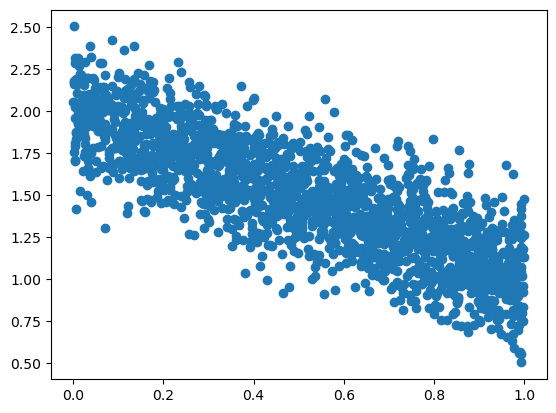

In [61]:
n = 2000
X = torch.rand(n)
X = torch.stack((torch.ones_like(X),X), dim=1)
beta_real = torch.Tensor([2.0,-1.0])
sigma = 0.2
y = X @ beta_real.T + sigma*(torch.randn(n))
plt.scatter(X[:,1],y)
plt.show()

In [62]:
bay_lr = BayesianLinearRegression(X, y, tau2=10, a=1, b=1)

In [63]:
bay_lr.fit(n_iter=5000, burn_in=2000, n_chains=3, step_size=0.01)

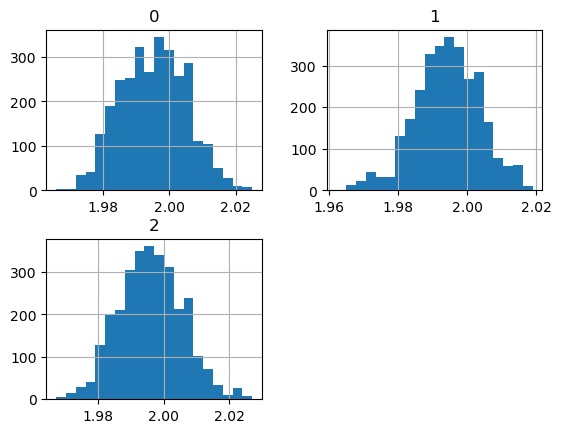

In [64]:
pd.DataFrame(bay_lr.beta_samples[:,:,0]).hist(bins=20)
plt.show()

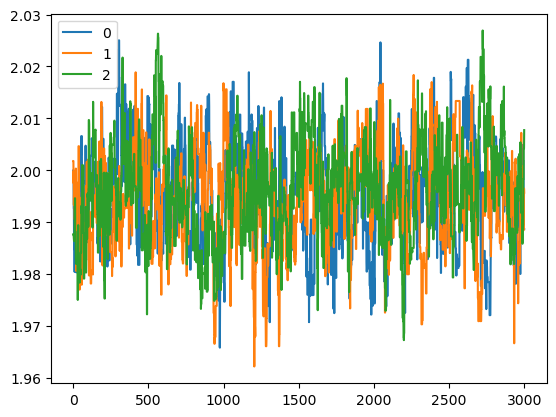

In [65]:
pd.DataFrame(bay_lr.beta_samples[:,:,0]).plot()
plt.show()

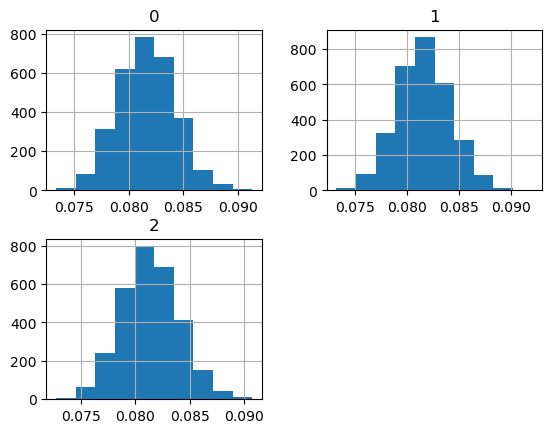

In [66]:
pd.DataFrame(bay_lr.score(X, y)).hist()
plt.show()

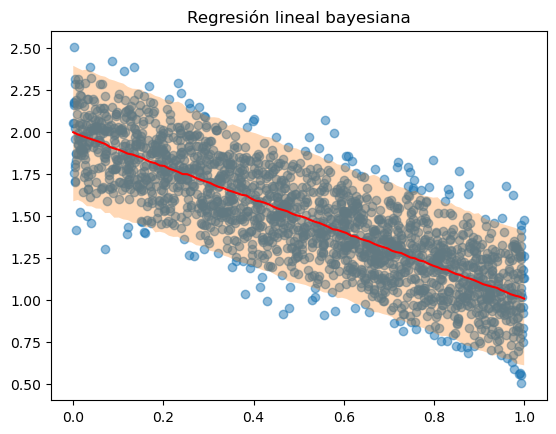

In [69]:
# Crear grid para graficar
x_grid = torch.linspace(X[:,1].min(), X[:,1].max(), 100)

X_grid = torch.stack((torch.ones_like(x_grid), x_grid), dim=1)

# Media predictiva
y_mean = bay_lr.predict_mean(X_grid)

# Intervalos de credibilidad
lower, upper = bay_lr.predict_ci(X_grid, alpha=0.05)

# Datos originales
X_data = X[:,1]
y_data = y

# Graficar
plt.figure()

plt.scatter(X_data, y_data, alpha=0.5, label="Datos")

plt.plot(x_grid, y_mean, label="Media posterior",color='red')

plt.fill_between(x_grid, lower, upper, alpha=0.3, label="Intervalo 95%")

#plt.legend()
#plt.xlabel("x")
#plt.ylabel("y")
plt.title("Regresión lineal bayesiana")

plt.show()

In [71]:
y_data

tensor([1.0774, 1.2954, 1.7452,  ..., 1.3747, 1.1244, 1.3541])